# Очистка и проверка выбросов таблицы secondary_market

In [1]:
import os
import sys

# Указание Директории
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Добавление корня проекта в sys.path (cwd уже переключён на корень)
sys.path.append(os.getcwd())
from src.boxplotting import plot_price_boxplot
from src.segmentation import (
    add_premium_flag,
    add_premium_flag_by_year,
    compare_premium_methods,
    add_new_moscow_flag,
    compare_old_vs_new_moscow_median,
    plot_old_vs_new_moscow_boxplot,
    plot_new_moscow_share_pie,
)

print(f"Текущая директория: {os.getcwd()}")

Текущая директория: D:\Moscow_rent_analysis


Проверка и очистка пустых ячеек

In [2]:
import pandas as pd
from pathlib import Path

os.makedirs('data/processed', exist_ok=True)
PROJECT_ROOT = Path(os.getcwd())
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

df_raw_secondary_market = pd.read_csv(RAW_DIR / 'secondary_market.csv')

# Проверка данных
print(f"Проверка данных")
print(f"Строк: {len(df_raw_secondary_market)}")
print(f"Столбцов: {len(df_raw_secondary_market.columns)}")
print(f"Пустых значений: {df_raw_secondary_market.isnull().sum().sum()}")

# Приведение к формату и очистка
df_clean_secondary_market = df_raw_secondary_market.copy()
df_clean_secondary_market['building_year'] = df_clean_secondary_market['building_year'].astype(int)
df_clean_secondary_market['date_posted'] = pd.to_datetime(df_clean_secondary_market['date_posted'])

#Проверка после очистки
print("\nПосле очистки:")
print(f"Строк: {len(df_clean_secondary_market)}")


Проверка данных
Строк: 50000
Столбцов: 26
Пустых значений: 0

После очистки:
Строк: 50000


Проверка выбросов

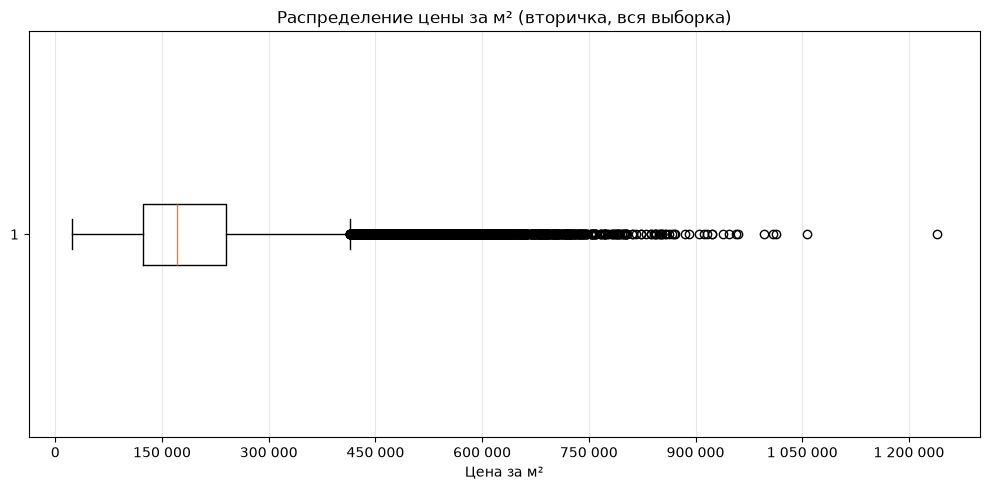

In [3]:
plot_price_boxplot(
    df_clean_secondary_market['price_per_sqm'],
    'Распределение цены за м² (вторичка, вся выборка)',
    delenia=12,
    width=10.0,
    height=5.0
)

Проверим правый "хвост" графика на ошибочные данные и выброски

In [4]:
df_clean_secondary_market.nlargest(15, 'price_per_sqm')[['id', 'price_per_sqm', 'district', 'total_area', 'price_rub', 'rooms']]

,id,price_per_sqm,district,total_area,price_rub,rooms
33580,S033581,1239100,Khamovniki,64.9,80367000,2
43133,S043134,1056100,Yakimanka,42.5,44869000,1
30360,S030361,1013600,Tverskoy,87.1,88296000,3
44133,S044134,1008500,Tverskoy,66.8,67365000,2
10793,S010794,996300,Presnensky,67.4,67144000,2
49780,S049781,959600,Arbat,32.4,31082000,1
19911,S019912,957400,Tverskoy,63.2,60551000,2
45801,S045802,946600,Khamovniki,73.3,69360000,2
34314,S034315,938200,Tverskoy,72.6,68136000,2
40336,S040337,923700,Khamovniki,74.1,68427000,2


Оказалось, что никаких ошибок нет, просто безумно дорогое элитное жилье в ЦАО

## Выделение премиум-сегмента

Разделим на 2 группы жилье: обычный сегмент и премиум-сегмент методом квартильного размаха

### Исправление методики: порог считается внутри года

**Здесь была методологическая ошибка, и ниже она разобрана, а не спрятана.**

Изначально порог премиум-сегмента считался один на всю таблицу: Q3 + 1.5 × IQR по всем объявлениям 2020-2026 годов сразу. Выглядело безобидно, но в разделе 8.5.2 глубокого анализа проверка показала, что это неверно.

Цены за период выросли, а порог зафиксирован на среднем уровне всего шестилетия. Из-за этого объявлению 2020 года нужно быть гораздо более выдающимся, чтобы получить метку премиума, чем объявлению 2026 года. Другими словами, `is_premium` частично кодировал не «дорогое жильё», а **«объявление размещено позже»**.

Правильный порог — свой для каждого года. Тогда премиум означает «дорогое относительно своего времени».

Ниже оба расчёта подряд: сначала старый, как было, потом новый, как стало, и сравнение.

**Шаг 1. Как было** — один порог на все годы (`add_premium_flag`). Функция намеренно оставлена в `src/segmentation.py`, чтобы ошибку можно было воспроизвести.

In [5]:
df_clean_secondary_market = add_premium_flag(df_clean_secondary_market, 'price_per_sqm')

Q1 = 123000
Q3 = 239500
IQR = 116500
Порог премиум-сегмента: 414250
is_premium
False    47304
True      2696
Name: count, dtype: int64

Доля премиум-сегмента: 5.4%


**Шаг 2. Как стало** — порог внутри каждого года (`add_premium_flag_by_year`). Эта строка перезаписывает `is_premium`, и дальше по ноутбуку и во всём проекте используется уже она.

In [6]:
df_clean_secondary_market = add_premium_flag_by_year(df_clean_secondary_market, 'price_per_sqm')

      Объявлений  Порог года  Премиум, шт  Премиум, %
Год                                                  
2020        7859    318275.0          430         5.5
2021        7883    367600.0          420         5.3
2022        7966    398938.0          448         5.6
2023        7964    438262.0          433         5.4
2024        7986    458650.0          429         5.4
2025        7747    443200.0          421         5.4
2026        2595    468000.0          134         5.2

Всего премиум-сегмента: 2715 (5.4%)


**Шаг 3. Что изменилось** — сравнение двух методов по годам.

In [7]:
premium_methods = compare_premium_methods(df_clean_secondary_market, 'price_per_sqm')
print()
print(premium_methods.to_string())

Общий порог по всей выборке: 414 250
Премиум по общему порогу:  2696 (5.4%)
Премиум по порогу года:    2715 (5.4%)

Сменили метку: 909 объявлений из 50000 (1.8%)
  были премиумом, перестали: 445
  не были премиумом, стали:  464

      Объявлений  Порог года  Премиум по общему порогу, %  Премиум по порогу года, %  Сменили метку, шт
Год                                                                                                    
2020        7859    318275.0                          2.0                        5.5                270
2021        7883    367600.0                          3.5                        5.3                144
2022        7966    398938.0                          5.0                        5.6                 50
2023        7964    438262.0                          6.6                        5.4                 90
2024        7986    458650.0                          7.6                        5.4                175
2025        7747    443200.0               

### Что дало исправление (вторичка)

Здесь искажение было самым сильным из трёх таблиц. Общий порог — 414 250 руб/м², а порог года уехал за период с 318 275 до 468 000, то есть **на +47%**.

По старому методу доля премиума выросла с **2.0% в 2020 до 8.0% в 2026 — вчетверо**, хотя рынок не расслаивался в четыре раза, просто дорожал целиком. По новому методу доля стоит на 5.2-5.6%, разброс в 1.1 раза.

Итоговая доля премиума при этом не поменялась (5.4% в обоих методах), но **909 объявлений сменили метку**: 445 перестали быть премиумом, 464 стали. Именно на этой таблице держится большая часть выводов проекта — регрессия, классификатор премиума, окупаемость, сверка с официальной статистикой, — поэтому всё, что ниже по пайплайну, пересчитано.

Построим для наглядности график-боксплот, исключающий премиум-сегмент квартиры

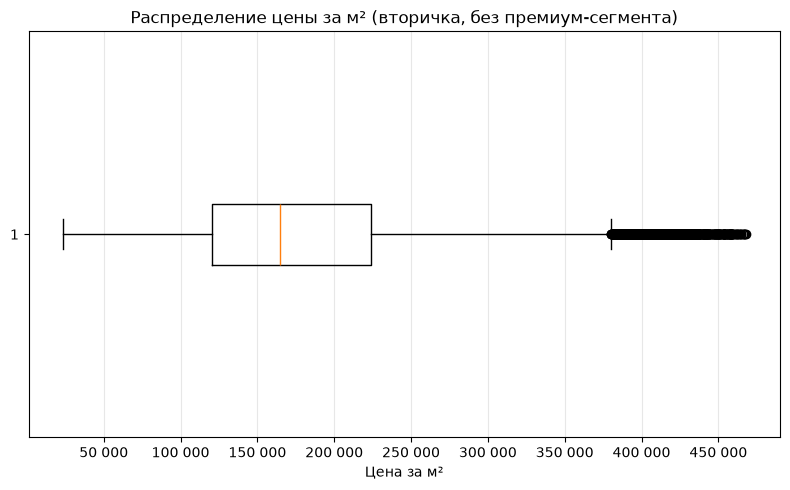

In [8]:
df_no_premium = df_clean_secondary_market[~df_clean_secondary_market['is_premium']]
plot_price_boxplot(
    df_no_premium['price_per_sqm'],
    'Распределение цены за м² (вторичка, без премиум-сегмента)',
    delenia=10,
    width=8.0,
    height=5.0
)

Заметим, что на первый взгляд в таблицах также есть несоответствие в колонке to_center_km слишком большие значения, вплоть до 600-700 км. Это присоединенная ранее или в течение периода "Новая Москва" в виде трех округов: "TAO", "NAO", "ZelAO"

## Выделение Новой Москвы

Разделим данные, аналогично с колонкой "is_premium"

In [9]:
df_clean_secondary_market = add_new_moscow_flag(df_clean_secondary_market)

is_new_moscow
False    41522
True      8478
Name: count, dtype: int64
Доля Новой Москвы: 17.0%


In [10]:
df_clean_secondary_market[df_clean_secondary_market['is_new_moscow']]['is_premium'].value_counts()

is_premium
False    8478
Name: count, dtype: int64

Ни один объект Новой Москвы не попал в премиум-сегмент (0 из 8478). Это количественно доказывает, что Новая Москва - принципиально иной, более доступный сегмент рынка, а не часть единого "московского" распределения цен.

Важно: порог премиум-сегмента (IQR) считается внутри каждого года по всей выборке этого года, включая Новую Москву, а не отдельно по Старой Москве. Это не искажает результат: Новая Москва - компактный кластер низких цен, полностью лежащий ниже Q1 и Q3, и не образует собственных выбросов сверху. Она не может "перетянуть" границу премиум-сегмента, поэтому отдельный пересчёт порога по Старой Москве не требуется.

## Визуализация разницы Новой и Старой Москвы

In [11]:
compare_old_vs_new_moscow_median(df_clean_secondary_market, 'price_per_sqm')

Старая Москва, медиана price_per_sqm: 188,500
Новая Москва, медиана price_per_sqm: 74,800
Разница: в 2.5 раз


## Бокс-плот

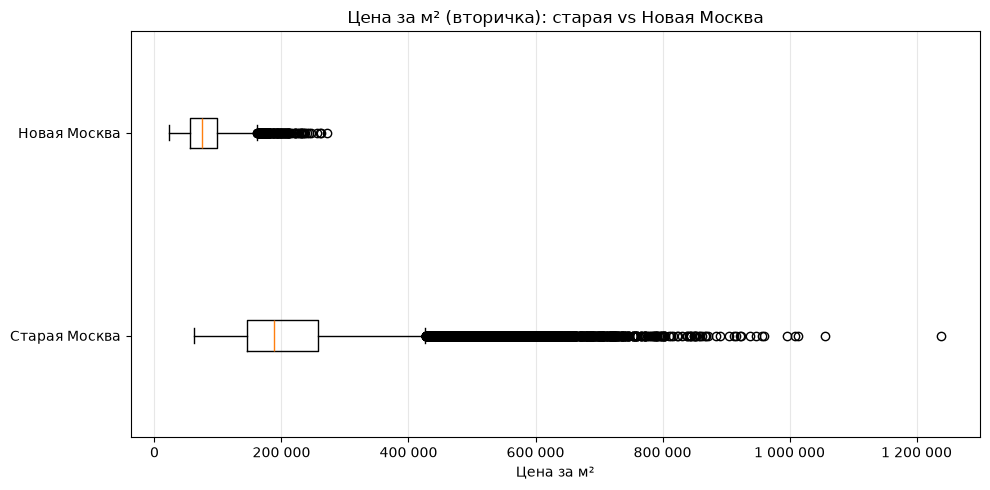

In [12]:
plot_old_vs_new_moscow_boxplot(df_clean_secondary_market, 'price_per_sqm', 'вторичка')

Сделаем вывод, что рынок Старой Москвы более разнороден - есть как бюджетные варианты, так и элитное жилье. Новая Москва более однородна по ценам.

## Круговая диаграмма

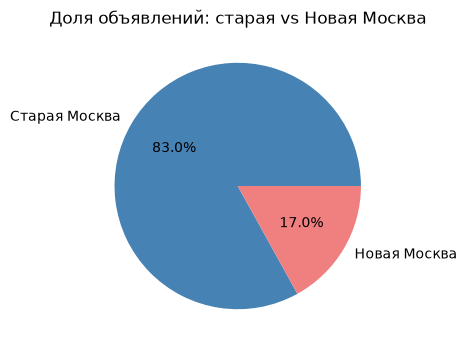

In [13]:
plot_new_moscow_share_pie(df_clean_secondary_market)

Сохраним новые данные в измененную таблицу processed

In [14]:
df_clean_secondary_market.to_csv('data/processed/clean_secondary_market.csv', index=False)